In [3]:
!pip install yfinance pandas xgboost scikit-learn matplotlib


C:\Users\nalin\AppData\Local\Temp\ipykernel_22748\222629935.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2020-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed


Mean Squared Error: 97.01422445789392


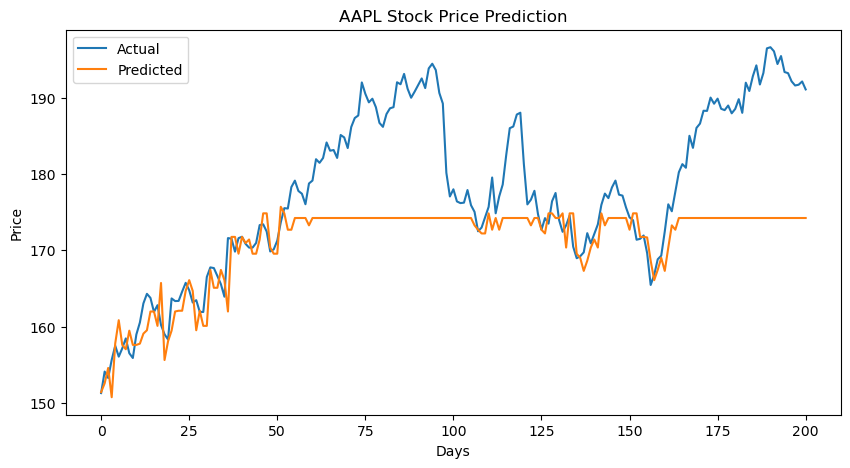

In [5]:
import yfinance as yf
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Download historical stock data (e.g., Apple)
data = yf.download('AAPL', start='2020-01-01', end='2023-12-31')

# Use only 'Close' prices and create lag features
data['Target'] = data['Close'].shift(-1)  # Predict next day's price
data = data[['Close', 'Target']].dropna()

# Features and target
X = data[['Close']]
y = data['Target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Train XGBoost regressor
model = XGBRegressor()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title('AAPL Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()
